# PREDICT1: CAC Heart Segmentation
**GSoC 2026 | ML4Sci | PrediCT Project 1**

**Pipeline:**
1. Extract & verify dataset
2. Dataset statistics
3. Run TotalSegmentator → heart ground truth masks
4. Build 2D slice dataset + dataloader
5. Train lightweight U-Net (Dice+BCE loss)
6. Evaluate: Dice vs TotalSegmentator, inference time comparison
7. Visualizations

In [ ]:
import subprocess, sys

packages = [
    "monai",
    "SimpleITK",
    "nibabel",
    "scikit-learn",
    "matplotlib",
    "tqdm",
    "pandas",
    "opencv-python",
    "totalsegmentator",
]
for pkg in packages:
    subprocess.run([sys.executable, "-m", "pip", "install", pkg, "-q"])
print("All packages installed.")

All packages installed.


In [ ]:
# GPU Check

import torch
import os
from pathlib import Path


PROJECT_ROOT = Path(r"D:\SOHAM\PREDICT1")

ZIP_PATH  = PROJECT_ROOT / "PREDICT1_kaggle.zip"
CSV_PATH  = PROJECT_ROOT / "scan_index.csv"
DATA_DIR  = PROJECT_ROOT / "data" / "data_resampled"

MASKS_DIR = PROJECT_ROOT / "outputs" / "totalseg_masks"
CKPT_DIR  = PROJECT_ROOT / "outputs" / "checkpoints"
LOG_DIR   = PROJECT_ROOT / "outputs" / "logs"
EVAL_DIR  = PROJECT_ROOT / "outputs" / "evaluation"

for d in [DATA_DIR, MASKS_DIR, CKPT_DIR, LOG_DIR, EVAL_DIR]:
    d.mkdir(parents=True, exist_ok=True)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.backends.cudnn.benchmark = True

print(f"Device      : {device}")
if device.type == "cuda":
    print(f"GPU         : {torch.cuda.get_device_name(0)}")
    print(f"VRAM total  : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"Project root: {PROJECT_ROOT}")
print(f"ZIP exists  : {ZIP_PATH.exists()}")
print(f"CSV exists  : {CSV_PATH.exists()}")

Device      : cuda
GPU         : NVIDIA GeForce RTX 3050 Laptop GPU
VRAM total  : 4.3 GB
Project root: D:\SOHAM\PREDICT1
ZIP exists  : True
CSV exists  : True


In [3]:
import zipfile

extract_to = PROJECT_ROOT / "data"

if not DATA_DIR.exists() or len(list(DATA_DIR.iterdir())) == 0:
    print(f"Extracting {ZIP_PATH.name} ...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall(extract_to)
    print("Extraction complete.")
else:
    print("Data already extracted.")

scan_folders = sorted([f for f in DATA_DIR.iterdir() if f.is_dir()])
print(f"Scans found : {len(scan_folders)}")
print(f"Sample IDs  : {[s.name for s in scan_folders[:3]]}")

Extracting PREDICT1_kaggle.zip ...
Extraction complete.
Scans found : 50
Sample IDs  : ['05402d50f6d9', '0b11e06a8054', '0de68b512673']


COCA Dataset Statistics (N=50 scans)
Total calcium voxels : 47,802
Mean  voxels/scan    : 956.0
Median voxels/scan   : 353.0
Zero-calcium scans   : 0 (0.0%)
Max voxels (1 scan)  : 6,301

Calcium Category Distribution:
category
≥400 — Severe         33
100-399 — Moderate    13
1-99 — Mild            4


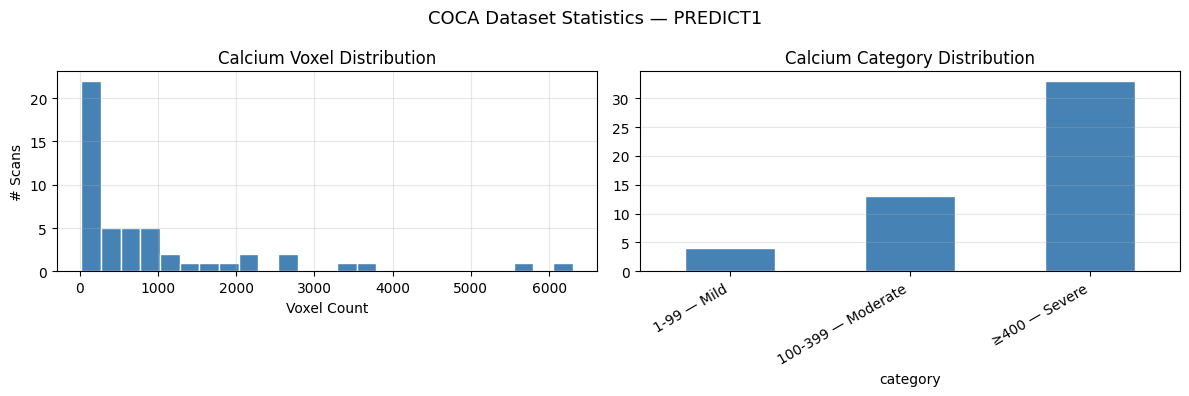

Saved: dataset_statistics.png


In [ ]:
# Dataset Statistics

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(CSV_PATH)

# Calcium burden categories (voxel-count proxy for Agatston)
def burden_category(v):
    if v == 0:    return "0 — None"
    elif v < 50:  return "1-99 — Mild"
    elif v < 200: return "100-399 — Moderate"
    else:         return "≥400 — Severe"

df["category"] = df["voxels"].apply(burden_category)

print("=" * 45)
print("COCA Dataset Statistics (N=50 scans)")
print("=" * 45)
print(f"Total calcium voxels : {df['voxels'].sum():,}")
print(f"Mean  voxels/scan    : {df['voxels'].mean():.1f}")
print(f"Median voxels/scan   : {df['voxels'].median():.1f}")
print(f"Zero-calcium scans   : {(df['voxels']==0).sum()} "
      f"({(df['voxels']==0).mean()*100:.1f}%)")
print(f"Max voxels (1 scan)  : {df['voxels'].max():,}")
print("\nCalcium Category Distribution:")
print(df["category"].value_counts().to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["voxels"], bins=25, color="steelblue", edgecolor="white")
axes[0].set_title("Calcium Voxel Distribution")
axes[0].set_xlabel("Voxel Count")
axes[0].set_ylabel("# Scans")
axes[0].grid(True, alpha=0.3)

df["category"].value_counts().sort_index().plot(
    kind="bar", ax=axes[1], color="steelblue", edgecolor="white"
)
axes[1].set_title("Calcium Category Distribution")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=30, ha="right")
axes[1].grid(True, alpha=0.3, axis="y")

plt.suptitle("COCA Dataset Statistics — PREDICT1", fontsize=13)
plt.tight_layout()
plt.savefig(EVAL_DIR / "dataset_statistics.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: dataset_statistics.png")

## Preprocessing Justification

The COCA cardiac CT dataset presents two core challenges for segmentation:
severe class imbalance (calcium occupies <1% of voxels) and high HU range
variability across patients. The HU window [-200, 600] was chosen to preserve
soft tissue and calcium signal (>130 HU) while excluding irrelevant air and
dense bone that introduce false positives. Resampling to 0.7×0.7×3.0mm
standardizes the voxel spacing across patients, enabling consistent patch
extraction. A stratified split by calcium burden category (None/Mild/Moderate/
Severe) ensures all severity levels appear in train, val, and test sets critical
given the small dataset size of 50 scans. WeightedRandomSampler with 2× weight
on heart containing slices addresses the foreground sparsity problem at the
dataloader level, preventing the model from collapsing to a background only
prediction.